# Heterogeneous GAT (paper-only graph, two relations)

## Encoder

- **Hetero graph**: paper-only with two directed edge types — `('paper','cites','paper')` and `('paper','cited_by','paper')`.
- **Per-relation parameters**: each relation has its own `GATConv` layer with its own attention weights. Citing-direction and cited-by-direction can be attended to differently.
- **HAN-style semantic attention** (Wang et al. 2019): after the per-relation messages are computed at each node, a tiny learnable softmax over relations decides their relative importance.

Architecture: 2 layers, 4 heads in layer 1, 1 head in layer 2, HIDDEN=256, OUTPUT=256.

Author representation: mean-pool of paper embeddings over history. No author embedding table. Fully inductive.


## Imports

We wire `GATConv` per relation manually so we can plug in the HAN aggregator. No need for `HeteroConv` since we are doing custom aggregation.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from pathlib import Path

from torch_geometric.nn import GATConv

## Reproducibility and device


In [2]:
SEED = 43
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Configuration

`OUTPUT_DIM=256`. HAN-specific knob is `SEMANTIC_ATTN_DIM=128` — the projection dimension inside the per-relation attention summary; standard HAN value, rarely tuned.

Edge types are hard-coded as `'cites'` and `'cited_by'`, matching what prep saves. The list `RELATIONS` is the only place to add a new relation.


In [3]:
# --- Paths ---
PROCESSED_DIR = Path("./data/processed_v2")
MODEL_OUT_DIR = Path("./models")
PLOTS_OUT_DIR = Path("./data")

# --- Negative strategy ---
NEG_STRATEGY = 'mixed'

# --- Hetero relations ---
RELATIONS = ['cites', 'cited_by']  # one GATConv per relation, per layer

# --- Encoder ---
INPUT_DIM = 768
HIDDEN_DIM = 256
OUTPUT_DIM = 256                   # parity with your v2 GAT run
GAT_HEADS_LAYER1 = 4
GAT_HEADS_LAYER2 = 1
GAT_NEGATIVE_SLOPE = 0.2
DROPOUT = 0.2
ATTN_DROPOUT = 0.0

# --- HAN-style semantic attention ---
SEMANTIC_ATTN_DIM = 128            # projection dim inside the relation-aggregator

# --- Decoder ---
DECODER_HIDDEN_DIM = 128
DECODER_DROPOUT = 0.0

# --- Optimization ---
LR = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 0.0

# --- Training ---
NUM_EPOCHS = 60
BATCH_SIZE = 512
EVAL_EVERY = 5
GNN_GRAD_SAMPLE_SIZE = 32
EVAL_BATCH_SIZE = 64

print(f"Data dir:      {PROCESSED_DIR}")
print(f"Relations:     {RELATIONS}")
print(f"NEG_STRATEGY:  {NEG_STRATEGY}")
print(f"Hetero GAT:    layers=2, heads_l1={GAT_HEADS_LAYER1}, heads_l2={GAT_HEADS_LAYER2}")
print(f"Dims:          {INPUT_DIM} -> {HIDDEN_DIM} -> {OUTPUT_DIM}, semantic_attn_dim={SEMANTIC_ATTN_DIM}")
print(f"Schedule:      {NUM_EPOCHS} epochs, batch {BATCH_SIZE}, eval every {EVAL_EVERY}")

Data dir:      data/processed_v2
Relations:     ['cites', 'cited_by']
NEG_STRATEGY:  mixed
Hetero GAT:    layers=2, heads_l1=4, heads_l2=1
Dims:          768 -> 256 -> 256, semantic_attn_dim=128
Schedule:      60 epochs, batch 512, eval every 5


## Step 1 — Load data

The validation/test bundles contain a `hetero_graph` (paper-only, two edge types) which is what we feed the encoder.


In [4]:
train_years = torch.load(PROCESSED_DIR / "train_years.pt", weights_only=False)
metadata = torch.load(PROCESSED_DIR / "metadata.pt", weights_only=False)
val_data = torch.load(PROCESSED_DIR / "val.pt", weights_only=False)

print(f"Training years ({len(train_years)}): {train_years}")
print(f"Embed dim: {metadata['embed_dim']}")
print(f"Val hetero graph node types: {val_data['hetero_graph'].node_types}")
print(f"Val hetero graph edge types: {val_data['hetero_graph'].edge_types}")
print(f"Val examples: {len(val_data['supervision']):,}")

assert metadata['embed_dim'] == INPUT_DIM, f"INPUT_DIM mismatch ({INPUT_DIM} vs {metadata['embed_dim']})"

Training years (12): [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Embed dim: 768
Val hetero graph node types: ['paper']
Val hetero graph edge types: [('paper', 'cites', 'paper'), ('paper', 'cited_by', 'paper')]
Val examples: 43,562


## Sanity peek

Confirms the schema and that the hetero graph has exactly the two relations we need.


In [5]:
sample_data = torch.load(PROCESSED_DIR / f"train_year_{train_years[0]}.pt", weights_only=False)
g = sample_data['hetero_graph']
print(f"Sample year {train_years[0]}: hetero graph nodes (paper only) = {g['paper'].num_nodes:,}")
for et in g.edge_types:
    print(f"  edge {et}: {g[et].edge_index.shape[1]:,} edges")
assert ('paper', 'cites', 'paper') in g.edge_types
assert ('paper', 'cited_by', 'paper') in g.edge_types
assert 'author' not in g.node_types, "Hetero graph still has author nodes — re-run v2 prep with Option-1 patch."
if sample_data['supervision']:
    ex = sample_data['supervision'][0]
    assert 'negatives_random' in ex and 'negatives_hard' in ex
    print(f"  example: {len(ex['positive_locals'])} pos, "
          f"{len(ex['negatives_random'])} rand-neg, "
          f"{len(ex['negatives_hard'])} hard-neg")

Sample year 2005: hetero graph nodes (paper only) = 107,163
  edge ('paper', 'cites', 'paper'): 644,493 edges
  edge ('paper', 'cited_by', 'paper'): 644,493 edges
  example: 3 pos, 15 rand-neg, 15 hard-neg


## Step 2 — HAN-style semantic attention

Given a list of `R` per-relation node-embedding tensors (each `(N, D)`) — one per relation — produce a single `(N, D)` aggregate where the contribution of each relation is weighted by a **learnable** scalar.

Procedure (HAN, Wang et al. WWW'19):
1. Project each relation's outputs through a shared `Linear(D, attn_dim)` + `tanh` non-linearity -> `z_r` of shape `(N, attn_dim)`.
2. Score each relation by averaging the dot product `q . z_r` across nodes -> one scalar per relation.
3. Softmax those `R` scalars -> relation weights `alpha in R^R`.
4. Output `sum_r alpha_r * h_r` of shape `(N, D)`.

Tiny module — `D x attn_dim + attn_dim` extra params per layer. The point is **the model decides relative importance of `cites` vs `cited_by` from data**, instead of the architect hard-coding `mean` or `sum`.


In [6]:
class SemanticAttention(nn.Module):
    """HAN-style attention over relations. Aggregates per-relation node embeddings."""
    def __init__(self, in_dim, attn_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, attn_dim)
        self.q = nn.Parameter(torch.empty(attn_dim))
        nn.init.xavier_uniform_(self.proj.weight)
        nn.init.zeros_(self.proj.bias)
        nn.init.normal_(self.q, mean=0.0, std=0.1)

    def forward(self, rel_outputs):
        # rel_outputs: list of R tensors, each (N, D)
        stacked = torch.stack(rel_outputs, dim=0)             # (R, N, D)
        z = torch.tanh(self.proj(stacked))                     # (R, N, attn_dim)
        scores = (z * self.q).sum(dim=-1).mean(dim=1)          # (R,)
        weights = F.softmax(scores, dim=0)                     # (R,)
        return (stacked * weights.view(-1, 1, 1)).sum(dim=0)   # (N, D)

    def relation_weights(self, rel_outputs):
        """Diagnostic: return the softmax weights without applying them. For interpretability."""
        stacked = torch.stack(rel_outputs, dim=0)
        z = torch.tanh(self.proj(stacked))
        scores = (z * self.q).sum(dim=-1).mean(dim=1)
        return F.softmax(scores, dim=0).detach()

# Sanity check: aggregator preserves shape, weights sum to 1
_sa = SemanticAttention(in_dim=8, attn_dim=4)
_outs = [torch.randn(5, 8), torch.randn(5, 8)]
with torch.no_grad():
    _agg = _sa(_outs)
    _w = _sa.relation_weights(_outs)
assert _agg.shape == (5, 8) and abs(_w.sum().item() - 1.0) < 1e-5
print(f"[PASS] SemanticAttention | weights sum = {_w.sum().item():.6f}, weights = {_w.tolist()}")
del _sa, _outs, _agg, _w

[PASS] SemanticAttention | weights sum = 1.000000, weights = [0.5116608142852783, 0.48833924531936646]


## Step 3 — Hetero GAT encoder

Two layers. Per layer:
1. Apply one `GATConv` per relation in `RELATIONS` (separate weights -> relation-specific attention over neighbors).
2. Aggregate the per-relation outputs with `SemanticAttention` (HAN).
3. (Layer 1 only) ELU non-linearity + dropout.

Forward signature accepts `edge_index_dict` — a `{relation: edge_index}` map — to keep the layer agnostic to which specific relations exist. Adding a third relation later is `RELATIONS.append('foo')` plus saving the corresponding edge type in prep.

Per-relation `GATConv` shapes:
- Layer 1: `in=INPUT_DIM`, `out=HIDDEN_DIM/heads_l1`, `heads=heads_l1`, `concat=True` -> `(N, HIDDEN_DIM)` per relation, then HAN -> `(N, HIDDEN_DIM)`.
- Layer 2: `in=HIDDEN_DIM`, `out=OUTPUT_DIM`, `heads=heads_l2`, `concat=False` (single-head output) -> `(N, OUTPUT_DIM)` per relation, then HAN -> `(N, OUTPUT_DIM)`.


In [7]:
class HeteroGATEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, relations,
                 heads_l1=4, heads_l2=1,
                 dropout=0.2, attn_dropout=0.0,
                 negative_slope=0.2, semantic_attn_dim=128):
        super().__init__()
        assert hidden_dim % heads_l1 == 0
        per_head_l1 = hidden_dim // heads_l1
        self.relations = list(relations)
        self.dropout = dropout

        # Layer 1: per-relation multi-head GAT
        self.conv1 = nn.ModuleDict({
            rel: GATConv(
                in_channels=input_dim,
                out_channels=per_head_l1,
                heads=heads_l1, concat=True,
                negative_slope=negative_slope, dropout=attn_dropout,
            )
            for rel in self.relations
        })
        self.attn1 = SemanticAttention(in_dim=hidden_dim, attn_dim=semantic_attn_dim)

        # Layer 2: per-relation single-head GAT (output)
        self.conv2 = nn.ModuleDict({
            rel: GATConv(
                in_channels=hidden_dim,
                out_channels=output_dim,
                heads=heads_l2, concat=(heads_l2 > 1),
                negative_slope=negative_slope, dropout=attn_dropout,
            )
            for rel in self.relations
        })
        self.attn2 = SemanticAttention(in_dim=output_dim, attn_dim=semantic_attn_dim)

    def forward(self, x, edge_index_dict):
        # Layer 1: per-relation message + HAN aggregation
        h_per_rel = [self.conv1[rel](x, edge_index_dict[rel]) for rel in self.relations]
        h = self.attn1(h_per_rel)                                   # (N, hidden_dim)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        # Layer 2: per-relation output + HAN aggregation
        h_per_rel = [self.conv2[rel](h, edge_index_dict[rel]) for rel in self.relations]
        return self.attn2(h_per_rel)                                # (N, output_dim)

    @torch.no_grad()
    def report_relation_weights(self, x, edge_index_dict):
        """Diagnostic: show learned relation importances at both layers (for sanity / paper figure)."""
        h1 = [self.conv1[rel](x, edge_index_dict[rel]) for rel in self.relations]
        w1 = self.attn1.relation_weights(h1)
        h_mid = F.elu(self.attn1(h1))
        h2 = [self.conv2[rel](h_mid, edge_index_dict[rel]) for rel in self.relations]
        w2 = self.attn2.relation_weights(h2)
        return {'layer1': dict(zip(self.relations, w1.tolist())),
                'layer2': dict(zip(self.relations, w2.tolist()))}

# Sanity check on the sample year
_te = HeteroGATEncoder(
    INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, RELATIONS,
    heads_l1=GAT_HEADS_LAYER1, heads_l2=GAT_HEADS_LAYER2,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT,
    negative_slope=GAT_NEGATIVE_SLOPE, semantic_attn_dim=SEMANTIC_ATTN_DIM,
)
_g = sample_data['hetero_graph']
_eid = {rel: _g['paper', rel, 'paper'].edge_index for rel in RELATIONS}
_te.eval()
with torch.no_grad():
    _out = _te(_g['paper'].x, _eid)
assert _out.shape == (_g['paper'].num_nodes, OUTPUT_DIM)
assert not torch.isnan(_out).any() and not torch.isinf(_out).any()
print(f"Encoder out: {_out.shape}")
print(f"Encoder params: {sum(p.numel() for p in _te.parameters()):,}")
print(f"Init relation weights: {_te.report_relation_weights(_g['paper'].x, _eid)}")
print("[PASS] HeteroGATEncoder")
del _te, _g, _eid, _out

Encoder out: torch.Size([107163, 256])
Encoder params: 593,408
Init relation weights: {'layer1': {'cites': 0.329377681016922, 'cited_by': 0.6706222891807556}, 'layer2': {'cites': 0.48587051033973694, 'cited_by': 0.5141295194625854}}
[PASS] HeteroGATEncoder


## Step 4 — MLP decoder

With `OUTPUT_DIM=256` the decoder input dim is `2*256 = 512`.


In [8]:
class MLPDecoder(nn.Module):
    def __init__(self, emb_dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(2 * emb_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, author_emb, paper_emb):
        combined = torch.cat([author_emb, paper_emb], dim=-1)
        h = F.relu(self.fc1(combined))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.fc2(h).squeeze(-1)

_td = MLPDecoder(OUTPUT_DIM, DECODER_HIDDEN_DIM, DECODER_DROPOUT)
_fa, _fp = torch.randn(16, OUTPUT_DIM), torch.randn(16, OUTPUT_DIM)
with torch.no_grad():
    _s = _td(_fa, _fp)
assert _s.shape == (16,) and not torch.isnan(_s).any() and _s.std() > 0
print(f"Decoder params: {sum(p.numel() for p in _td.parameters()):,}")
print("[PASS] decoder")
del _td, _fa, _fp, _s

Decoder params: 65,793
[PASS] decoder


## Step 5 — Author mean-pool, BPR loss, negative-sampling helper

Three small utilities. Mean-pool produces author embeddings inductively; BPR optimizes ranking; `get_train_negatives` picks training negatives from the pre-computed lists per `NEG_STRATEGY`.


In [9]:
def compute_author_embeddings(paper_embeddings, supervision_examples):
    embs = []
    for ex in supervision_examples:
        hids = torch.tensor(ex['history_locals'], dtype=torch.long, device=paper_embeddings.device)
        embs.append(paper_embeddings[hids].mean(dim=0))
    return torch.stack(embs)

def bpr_loss(pos_scores, neg_scores):
    diff = pos_scores.unsqueeze(1) - neg_scores.unsqueeze(0)
    return -F.logsigmoid(diff).mean()

def get_train_negatives(ex, strategy):
    if strategy == 'random':
        return list(ex['negatives_random'])
    if strategy == 'hard':
        return list(ex['negatives_hard'])
    n = len(ex['negatives_random'])
    half = n // 2
    return list(ex['negatives_random'][:half]) + list(ex['negatives_hard'][:n - half])

# Quick sanity
assert abs(bpr_loss(torch.tensor([0., 0.]), torch.tensor([0., 0.])).item() - 0.6931) < 0.01
print("[PASS] utilities")

[PASS] utilities


## Step 6 — Hetero-graph helpers

Two tiny helpers to keep the rest of the code clean.

- `get_edge_index_dict(g)` extracts `{relation: edge_index}` from a saved `HeteroData` (paper-only).
- `move_hetero_to_device(g, device)` moves the paper features and every paper–paper edge index to the requested device. Used at the start of train/eval to push the year's graph to GPU.

In [10]:
def get_edge_index_dict(g, relations=RELATIONS):
    return {rel: g['paper', rel, 'paper'].edge_index for rel in relations}

def move_hetero_to_device(g, device, relations=RELATIONS):
    g['paper'].x = g['paper'].x.to(device)
    for rel in relations:
        g['paper', rel, 'paper'].edge_index = g['paper', rel, 'paper'].edge_index.to(device)
    return g

## Step 7 — Train one year

Encode-once-detach + final small GNN-grad pass, adapted to the hetero forward signature `(x, edge_index_dict)`.


In [11]:
def train_one_year(encoder, decoder, optimizer, year_data, device,
                   batch_size=512, gnn_sample_size=32, grad_clip=0.0,
                   neg_strategy='mixed'):
    encoder.train(); decoder.train()
    g = move_hetero_to_device(year_data['hetero_graph'], device)
    eid = get_edge_index_dict(g)
    examples = year_data['supervision']
    if not examples:
        return 0.0

    paper_embs = encoder(g['paper'].x, eid).detach()

    indices = list(range(len(examples)))
    random.shuffle(indices)
    total_loss, num_batches = 0.0, 0

    for batch_start in range(0, len(indices), batch_size):
        bidx = indices[batch_start:batch_start + batch_size]
        bex = [examples[i] for i in bidx]
        author_embs = compute_author_embeddings(paper_embs, bex)

        all_a, all_p, bounds = [], [], []
        offset = 0
        for i, ex in enumerate(bex):
            negs = get_train_negatives(ex, neg_strategy)
            if not negs:
                continue
            n_pos, n_neg = len(ex['positive_locals']), len(negs)
            pos_ids = torch.tensor(ex['positive_locals'], dtype=torch.long, device=device)
            neg_ids = torch.tensor(negs, dtype=torch.long, device=device)
            all_a.append(author_embs[i].unsqueeze(0).expand(n_pos + n_neg, -1))
            all_p.append(torch.cat([paper_embs[pos_ids], paper_embs[neg_ids]], dim=0))
            bounds.append((offset, n_pos, n_neg))
            offset += n_pos + n_neg
        if not all_a:
            continue

        flat_a = torch.cat(all_a, dim=0)
        flat_p = torch.cat(all_p, dim=0)
        scores = decoder(flat_a, flat_p)

        batch_loss = torch.tensor(0.0, device=device)
        for start, n_pos, n_neg in bounds:
            ps = scores[start:start + n_pos]
            ns = scores[start + n_pos:start + n_pos + n_neg]
            batch_loss = batch_loss + bpr_loss(ps, ns)
        batch_loss = batch_loss / len(bounds)

        optimizer.zero_grad()
        batch_loss.backward()
        if grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(
                list(encoder.parameters()) + list(decoder.parameters()),
                max_norm=grad_clip,
            )
        optimizer.step()
        total_loss += batch_loss.item()
        num_batches += 1

    # Single GNN-grad pass so the encoder also learns
    sample = random.sample(examples, min(gnn_sample_size, len(examples)))
    pe_grad = encoder(g['paper'].x, eid)
    ae = compute_author_embeddings(pe_grad, sample)
    gnn_loss = torch.tensor(0.0, device=device)
    for i, ex in enumerate(sample):
        negs = get_train_negatives(ex, neg_strategy)
        if not negs:
            continue
        a = ae[i]
        pos_ids = torch.tensor(ex['positive_locals'], dtype=torch.long, device=device)
        neg_ids = torch.tensor(negs, dtype=torch.long, device=device)
        ps = decoder(a.unsqueeze(0).expand(len(pos_ids), -1), pe_grad[pos_ids])
        ns = decoder(a.unsqueeze(0).expand(len(neg_ids), -1), pe_grad[neg_ids])
        gnn_loss = gnn_loss + bpr_loss(ps, ns)
    gnn_loss = gnn_loss / max(len(sample), 1)
    optimizer.zero_grad()
    gnn_loss.backward()
    if grad_clip > 0:
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder.parameters()),
            max_norm=grad_clip,
        )
    optimizer.step()

    del paper_embs, pe_grad
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return total_loss / max(num_batches, 1)

### Sanity test — training step on the sample year

Two consecutive train steps; confirm finite, positive, changing loss.

In [12]:
te = HeteroGATEncoder(
    INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, RELATIONS,
    heads_l1=GAT_HEADS_LAYER1, heads_l2=GAT_HEADS_LAYER2,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT,
    negative_slope=GAT_NEGATIVE_SLOPE, semantic_attn_dim=SEMANTIC_ATTN_DIM,
).to(device)
td = MLPDecoder(OUTPUT_DIM, DECODER_HIDDEN_DIM, DECODER_DROPOUT).to(device)
to_ = torch.optim.Adam(list(te.parameters()) + list(td.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
l1 = train_one_year(te, td, to_, sample_data, device,
                    batch_size=32, gnn_sample_size=GNN_GRAD_SAMPLE_SIZE,
                    grad_clip=GRAD_CLIP_NORM, neg_strategy=NEG_STRATEGY)
l2 = train_one_year(te, td, to_, sample_data, device,
                    batch_size=32, gnn_sample_size=GNN_GRAD_SAMPLE_SIZE,
                    grad_clip=GRAD_CLIP_NORM, neg_strategy=NEG_STRATEGY)
print(f"step1={l1:.4f}  step2={l2:.4f}  changed={abs(l1-l2)>1e-6}")
assert l1 > 0 and not np.isnan(l1) and not np.isinf(l1)
print("[PASS] training step")
del te, td, to_

step1=0.6829  step2=0.6767  changed=True
[PASS] training step


## Step 8 — Eval on the 1K mixed candidate pool

Encode call signature: `(x, edge_index_dict)`. Encode on GPU, score on CPU, return Hits@10 + MRR. Reads `negative_locals_mixed`.


In [13]:
@torch.no_grad()
def evaluate(encoder, decoder, eval_data, device, eval_batch_size=64):
    encoder.eval(); decoder.eval()
    g = move_hetero_to_device(eval_data['hetero_graph'], device)
    eid = get_edge_index_dict(g)
    examples = eval_data['supervision']
    if not examples:
        return {'hits@10': 0.0, 'mrr': 0.0, 'num_authors': 0}

    paper_embs = encoder(g['paper'].x, eid).cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    decoder_cpu = decoder.cpu()

    hits10, mrrs = [], []
    for batch_start in range(0, len(examples), eval_batch_size):
        for ex in examples[batch_start:batch_start + eval_batch_size]:
            hids = torch.tensor(ex['history_locals'], dtype=torch.long)
            a = paper_embs[hids].mean(dim=0)
            pos = ex['positive_locals']
            neg = ex['negative_locals_mixed']
            cand = pos + neg
            cids = torch.tensor(cand, dtype=torch.long)
            cembs = paper_embs[cids]
            scores = decoder_cpu(a.unsqueeze(0).expand(len(cand), -1), cembs)
            _, ranked = scores.sort(descending=True)
            n_pos = len(pos)
            best = float('inf')
            for rk, idx in enumerate(ranked.tolist()):
                if idx < n_pos:
                    best = rk + 1; break
            hits10.append(1.0 if best <= 10 else 0.0)
            mrrs.append(1.0 / best if best != float('inf') else 0.0)
    decoder.to(device)
    return {'hits@10': float(np.mean(hits10)), 'mrr': float(np.mean(mrrs)), 'num_authors': len(examples)}

## Step 9 — Full-pool eval (T1)

Ranks against every paper in the pre-test graph using `known_locals` to mask own/previously-cited papers.


In [14]:
@torch.no_grad()
def evaluate_full_pool(encoder, decoder, eval_data, device):
    encoder.eval(); decoder.eval()
    examples = eval_data['supervision']
    if not examples:
        return {'hits@10': 0.0, 'mrr': 0.0, 'num_authors': 0}
    if 'known_locals' not in examples[0]:
        raise KeyError("Full-pool eval requires 'known_locals'. Re-run prep with BUILD_FULL_POOL_TEST=True.")

    g = move_hetero_to_device(eval_data['hetero_graph'], device)
    eid = get_edge_index_dict(g)
    paper_embs = encoder(g['paper'].x, eid)  # (N, D) on GPU
    N = paper_embs.shape[0]

    hits10, mrrs = [], []
    for ex in examples:
        hids = torch.tensor(ex['history_locals'], dtype=torch.long, device=device)
        a = paper_embs[hids].mean(dim=0)
        pos = set(ex['positive_locals'])
        known_only = set(ex['known_locals']) - pos

        scores = decoder(a.unsqueeze(0).expand(N, -1), paper_embs)
        if known_only:
            mask = torch.tensor(list(known_only), dtype=torch.long, device=device)
            scores[mask] = float('-inf')

        pos_tensor = torch.tensor(list(pos), dtype=torch.long, device=device)
        _, ranked = scores.sort(descending=True)
        in_pos = torch.isin(ranked, pos_tensor)
        nz = in_pos.nonzero()
        best = (nz[0].item() + 1) if nz.numel() > 0 else float('inf')
        hits10.append(1.0 if best <= 10 else 0.0)
        mrrs.append(1.0 / best if best != float('inf') else 0.0)
    return {'hits@10': float(np.mean(hits10)), 'mrr': float(np.mean(mrrs)), 'num_authors': len(examples)}

## Step 10 — Initialize model + optimizer

Single Adam covers encoder + decoder. Param count breakdown is printed for sanity, including:
- 2 per-relation GATConv (layer 1, in=768)
- 2 per-relation GATConv (layer 2, in=256, out=256)
- 2 SemanticAttention modules
- Decoder

Larger than a homogeneous variant because relations have separate weight matrices.


In [15]:
encoder = HeteroGATEncoder(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM,
    relations=RELATIONS,
    heads_l1=GAT_HEADS_LAYER1, heads_l2=GAT_HEADS_LAYER2,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT,
    negative_slope=GAT_NEGATIVE_SLOPE, semantic_attn_dim=SEMANTIC_ATTN_DIM,
).to(device)
decoder = MLPDecoder(OUTPUT_DIM, DECODER_HIDDEN_DIM, DECODER_DROPOUT).to(device)
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)
n_enc = sum(p.numel() for p in encoder.parameters())
n_dec = sum(p.numel() for p in decoder.parameters())
print(f"Encoder params: {n_enc:,}")
print(f"Decoder params: {n_dec:,}")
print(f"Total:          {n_enc + n_dec:,}")
print(f"Training:       {NUM_EPOCHS} epochs, batch {BATCH_SIZE}, eval every {EVAL_EVERY}, NEG_STRATEGY={NEG_STRATEGY}")
print(f"Years:          {train_years}")

Encoder params: 593,408
Decoder params: 65,793
Total:          659,201
Training:       60 epochs, batch 512, eval every 5, NEG_STRATEGY=mixed
Years:          [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]


## Step 11 — Training loop

Per epoch: iterate years (load -> train -> free), eval every `EVAL_EVERY` epochs. After every eval we additionally print the **learned per-relation attention weights** at each layer — a diagnostic for whether the model thinks one direction dominates.


In [16]:
train_losses, val_hits, val_mrrs, eval_epochs = [], [], [], []
rel_weight_history = []  # per-eval layer1/layer2 weights

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_losses = []
    for year in train_years:
        yd = torch.load(PROCESSED_DIR / f"train_year_{year}.pt", weights_only=False)
        l = train_one_year(
            encoder, decoder, optimizer, yd, device,
            batch_size=BATCH_SIZE,
            gnn_sample_size=GNN_GRAD_SAMPLE_SIZE,
            grad_clip=GRAD_CLIP_NORM,
            neg_strategy=NEG_STRATEGY,
        )
        epoch_losses.append(l)
        del yd
    avg = float(np.mean(epoch_losses))
    train_losses.append(avg)

    if epoch % EVAL_EVERY == 0 or epoch == NUM_EPOCHS:
        v = evaluate(encoder, decoder, val_data, device, EVAL_BATCH_SIZE)
        val_hits.append(v['hits@10']); val_mrrs.append(v['mrr']); eval_epochs.append(epoch)

        # Diagnostic: relation weights at this checkpoint
        encoder.eval()
        with torch.no_grad():
            g = move_hetero_to_device(val_data['hetero_graph'], device)
            rw = encoder.report_relation_weights(g['paper'].x, get_edge_index_dict(g))
        rel_weight_history.append({'epoch': epoch, **rw})

        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Loss {avg:.4f} | "
              f"Val Hits@10 {v['hits@10']:.4f} | Val MRR {v['mrr']:.4f}")
        print(f"           rel-weights: layer1={ {k: f'{x:.3f}' for k, x in rw['layer1'].items()} }, "
              f"layer2={ {k: f'{x:.3f}' for k, x in rw['layer2'].items()} }")
    else:
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Loss {avg:.4f}")

Epoch   1/60 | Loss 0.6383
Epoch   2/60 | Loss 0.6076
Epoch   3/60 | Loss 0.5806
Epoch   4/60 | Loss 0.5589
Epoch   5/60 | Loss 0.5448 | Val Hits@10 0.1653 | Val MRR 0.0684
           rel-weights: layer1={'cites': '0.000', 'cited_by': '1.000'}, layer2={'cites': '1.000', 'cited_by': '0.000'}
Epoch   6/60 | Loss 0.5249
Epoch   7/60 | Loss 0.5088
Epoch   8/60 | Loss 0.4898
Epoch   9/60 | Loss 0.4792
Epoch  10/60 | Loss 0.4813 | Val Hits@10 0.2672 | Val MRR 0.1127
           rel-weights: layer1={'cites': '0.001', 'cited_by': '0.999'}, layer2={'cites': '0.888', 'cited_by': '0.112'}
Epoch  11/60 | Loss 0.4644
Epoch  12/60 | Loss 0.4525
Epoch  13/60 | Loss 0.4218
Epoch  14/60 | Loss 0.4124
Epoch  15/60 | Loss 0.3921 | Val Hits@10 0.3477 | Val MRR 0.1517
           rel-weights: layer1={'cites': '0.077', 'cited_by': '0.923'}, layer2={'cites': '0.943', 'cited_by': '0.057'}
Epoch  16/60 | Loss 0.3752
Epoch  17/60 | Loss 0.3632
Epoch  18/60 | Loss 0.3616
Epoch  19/60 | Loss 0.3516
Epoch  20/60 | L

## Step 12 — Plot training curves

Loss + val Hits@10 + val MRR. Saves to `data/hetero_gat_v2_training_<NEG_STRATEGY>.png`.


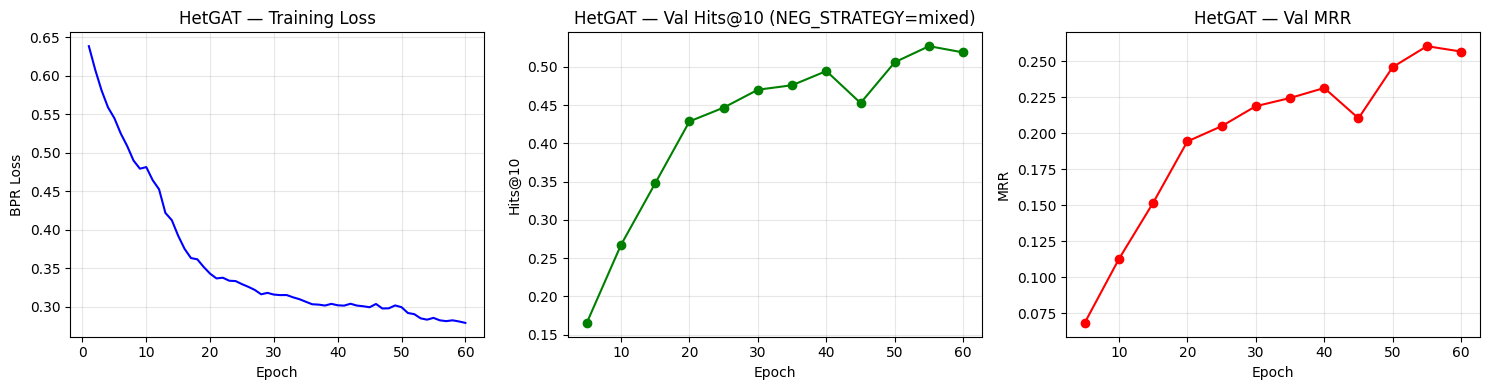

Best val Hits@10: 0.5270 (epoch 55)
Best val MRR:     0.2604 (epoch 55)

Final relation weights:
  layer1: {'cites': 0.1348809003829956, 'cited_by': 0.8651190400123596}
  layer2: {'cites': 0.7515921592712402, 'cited_by': 0.24840784072875977}


In [17]:
import matplotlib.pyplot as plt

PLOTS_OUT_DIR.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(range(1, len(train_losses) + 1), train_losses, 'b-')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BPR Loss')
axes[0].set_title('HetGAT — Training Loss'); axes[0].grid(True, alpha=0.3)
axes[1].plot(eval_epochs, val_hits, 'g-o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Hits@10')
axes[1].set_title(f'HetGAT — Val Hits@10 (NEG_STRATEGY={NEG_STRATEGY})'); axes[1].grid(True, alpha=0.3)
axes[2].plot(eval_epochs, val_mrrs, 'r-o')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MRR')
axes[2].set_title('HetGAT — Val MRR'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PLOTS_OUT_DIR / f'hetero_gat_v2_training_{NEG_STRATEGY}.png'), dpi=100, bbox_inches='tight')
plt.show()
if val_hits:
    print(f"Best val Hits@10: {max(val_hits):.4f} (epoch {eval_epochs[int(np.argmax(val_hits))]})")
    print(f"Best val MRR:     {max(val_mrrs):.4f} (epoch {eval_epochs[int(np.argmax(val_mrrs))]})")
if rel_weight_history:
    print(f"\nFinal relation weights:")
    print(f"  layer1: {rel_weight_history[-1]['layer1']}")
    print(f"  layer2: {rel_weight_history[-1]['layer2']}")

## Step 13 — Final test (1K mixed + full pool)

Two-regime evaluation.


In [18]:
test_data = torch.load(PROCESSED_DIR / "test.pt", weights_only=False)

test_1k = evaluate(encoder, decoder, test_data, device, EVAL_BATCH_SIZE)
print("=" * 50)
print(f"Hetero GAT v2 (NEG_STRATEGY={NEG_STRATEGY}) — TEST")
print("=" * 50)
print(f"\n[1K mixed pool, 50/50 hard/random]")
print(f"  Hits@10: {test_1k['hits@10']:.4f}")
print(f"  MRR:     {test_1k['mrr']:.4f}")
print(f"  Authors: {test_1k['num_authors']}")

test_full = evaluate_full_pool(encoder, decoder, test_data, device)
print(f"\n[Full pool — every paper in the pre-test graph]")
print(f"  Hits@10: {test_full['hits@10']:.4f}")
print(f"  MRR:     {test_full['mrr']:.4f}")
print(f"  Authors: {test_full['num_authors']}")

# Final relation-attention diagnostic on the test graph
encoder.eval()
with torch.no_grad():
    g = move_hetero_to_device(test_data['hetero_graph'], device)
    rw_test = encoder.report_relation_weights(g['paper'].x, get_edge_index_dict(g))
print(f"\nLearned relation weights at test time:")
print(f"  layer1: { {k: f'{x:.3f}' for k, x in rw_test['layer1'].items()} }")
print(f"  layer2: { {k: f'{x:.3f}' for k, x in rw_test['layer2'].items()} }")

Hetero GAT v2 (NEG_STRATEGY=mixed) — TEST

[1K mixed pool, 50/50 hard/random]
  Hits@10: 0.5305
  MRR:     0.2644
  Authors: 37046

[Full pool — every paper in the pre-test graph]
  Hits@10: 0.0063
  MRR:     0.0044
  Authors: 37046

Learned relation weights at test time:
  layer1: {'cites': '0.135', 'cited_by': '0.865'}
  layer2: {'cites': '0.752', 'cited_by': '0.248'}


## Step 14 — Save model

Persist encoder + decoder + config + both test numbers + relation-weight history to `models/hetero_gat_v2_<NEG_STRATEGY>.pt`. The relation weights over training are useful for inspecting how the model's preference between `cites` and `cited_by` evolves.


In [19]:
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
save_path = MODEL_OUT_DIR / f"hetero_gat_v2_{NEG_STRATEGY}.pt"

torch.save({
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'config': {
        'input_dim': INPUT_DIM, 'hidden_dim': HIDDEN_DIM, 'output_dim': OUTPUT_DIM,
        'relations': RELATIONS,
        'gat_heads_layer1': GAT_HEADS_LAYER1, 'gat_heads_layer2': GAT_HEADS_LAYER2,
        'gat_negative_slope': GAT_NEGATIVE_SLOPE,
        'dropout': DROPOUT, 'attn_dropout': ATTN_DROPOUT,
        'semantic_attn_dim': SEMANTIC_ATTN_DIM,
        'decoder_hidden_dim': DECODER_HIDDEN_DIM, 'decoder_dropout': DECODER_DROPOUT,
        'lr': LR, 'weight_decay': WEIGHT_DECAY, 'grad_clip_norm': GRAD_CLIP_NORM,
        'num_epochs': NUM_EPOCHS, 'batch_size': BATCH_SIZE,
        'gnn_grad_sample_size': GNN_GRAD_SAMPLE_SIZE,
        'neg_strategy': NEG_STRATEGY,
        'seed': SEED,
    },
    'val_best': {'hits@10': max(val_hits) if val_hits else 0.0,
                 'mrr': max(val_mrrs) if val_mrrs else 0.0},
    'test_1k_mixed': test_1k,
    'test_full_pool': test_full,
    'train_losses': train_losses,
    'val_hits': val_hits, 'val_mrrs': val_mrrs, 'eval_epochs': eval_epochs,
    'rel_weight_history': rel_weight_history,
    'rel_weights_test': rw_test,
    'data_version': 'v2',
    'fos_level': metadata.get('fos_level'),
}, save_path)
print(f"Saved {save_path}")

Saved models/hetero_gat_v2_mixed.pt


## Summary

| Metric | Value |
|---|---|
| NEG_STRATEGY | (see config) |
| Best val Hits@10 (1K mixed) | (see plot) |
| Test Hits@10 (1K mixed) | (last eval cell) |
| Test Hits@10 (full pool) | (last eval cell) |
| Final relation weights | (last eval cell) |

**Re-run for ablation**: change `NEG_STRATEGY` to `'random'` or `'hard'` and re-run all cells.

**Bonus interpretability**: the saved `rel_weight_history` lets you plot how the model's preference for `cites` vs `cited_by` evolves across training.


In [ ]:
# === Continue training: +50 epochs, replot, retest (2-layer HetGAT) ===                                                                                                                                      
EXTRA_EPOCHS = 50                                                                                                                                                                                             
start_epoch = len(train_losses) + 1                                                                                                                                                                           
end_epoch = len(train_losses) + EXTRA_EPOCHS                                                                                                                                                                  
prev_total = len(train_losses)                                                                                                                                                                                
                                                                                                                                                                                                            
print(f"Resuming from epoch {prev_total}; training epochs {start_epoch}..{end_epoch}  (seed={SEED})")                                                                                                         
                                                                                                                                                                                                            
for epoch in range(start_epoch, end_epoch + 1):                                                                                                                                                               
  epoch_losses = []                                                                                                                                                                                       
  for year in train_years:
      yd = torch.load(PROCESSED_DIR / f"train_year_{year}.pt", weights_only=False)
      l = train_one_year(                                                                                                                                                                                   
          encoder, decoder, optimizer, yd, device,
          batch_size=BATCH_SIZE,                                                                                                                                                                            
          gnn_sample_size=GNN_GRAD_SAMPLE_SIZE,                                                                                                                                                             
          grad_clip=GRAD_CLIP_NORM,
          neg_strategy=NEG_STRATEGY,                                                                                                                                                                        
      )                                                                                                                                                                                                   
      epoch_losses.append(l)                                                                                                                                                                                
      del yd                                                                                                                                                                                              
  avg = float(np.mean(epoch_losses))
  train_losses.append(avg)                                                                                                                                                                                  

  if epoch % EVAL_EVERY == 0 or epoch == end_epoch:                                                                                                                                                         
      v = evaluate(encoder, decoder, val_data, device, EVAL_BATCH_SIZE)                                                                                                                                   
      val_hits.append(v['hits@10']); val_mrrs.append(v['mrr']); eval_epochs.append(epoch)                                                                                                                   
      encoder.eval()                                                                                                                                                                                        
      with torch.no_grad():                                                                                                                                                                                 
          g = move_hetero_to_device(val_data['hetero_graph'], device)                                                                                                                                       
          rw = encoder.report_relation_weights(g['paper'].x, get_edge_index_dict(g))                                                                                                                      
      rel_weight_history.append({'epoch': epoch, **rw})                                                                                                                                                     
      print(f"Epoch {epoch:>3}/{end_epoch} | Loss {avg:.4f} | "
            f"Val Hits@10 {v['hits@10']:.4f} | Val MRR {v['mrr']:.4f}")                                                                                                                                     
      print(f"           rel-weights: layer1=" + str({k: f'{x:.3f}' for k, x in rw['layer1'].items()})                                                                                                      
            + f", layer2=" + str({k: f'{x:.3f}' for k, x in rw['layer2'].items()}))                                                                                                                         
  else:                                                                                                                                                                                                     
      print(f"Epoch {epoch:>3}/{end_epoch} | Loss {avg:.4f}")                                                                                                                                             
                                                                                                                                                                                                            
# --- Replot full history with resume marker ---                                                                                                                                                            
import matplotlib.pyplot as plt                                                                                                                                                                               
fig, axes = plt.subplots(1, 3, figsize=(15, 4))                                                                                                                                                               
axes[0].plot(range(1, len(train_losses) + 1), train_losses, 'b-')
axes[0].axvline(prev_total, color='gray', linestyle='--', alpha=0.6, label=f'resumed @ epoch {prev_total}')                                                                                                   
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BPR Loss')                                                                                                                                                   
axes[0].set_title(f'HetGAT-2L — Training Loss (total {len(train_losses)} epochs, seed={SEED})')                                                                                                               
axes[0].grid(True, alpha=0.3); axes[0].legend()                                                                                                                                                               
axes[1].plot(eval_epochs, val_hits, 'g-o')                                                                                                                                                                  
axes[1].axvline(prev_total, color='gray', linestyle='--', alpha=0.6)                                                                                                                                          
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Hits@10')                                                                                                                                                  
axes[1].set_title(f'HetGAT-2L — Val Hits@10 (NEG_STRATEGY={NEG_STRATEGY})')                                                                                                                                   
axes[1].grid(True, alpha=0.3)                                                                                                                                                                                 
axes[2].plot(eval_epochs, val_mrrs, 'r-o')                                                                                                                                                                    
axes[2].axvline(prev_total, color='gray', linestyle='--', alpha=0.6)                                                                                                                                          
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MRR')                                                                                                                                                      
axes[2].set_title('HetGAT-2L — Val MRR'); axes[2].grid(True, alpha=0.3)                                                                                                                                       
plt.tight_layout()                                                                                                                                                                                          
plt.savefig(str(PLOTS_OUT_DIR / f'hetero_gat_v2_training_{NEG_STRATEGY}_seed{SEED}_ep{len(train_losses)}.png'),                                                                                               
          dpi=100, bbox_inches='tight')                                                                                                                                                                     
plt.show()                                                                                                                                                                                                    
                                                                                                                                                                                                            
print(f"\nBest val Hits@10 (over {len(train_losses)} epochs): {max(val_hits):.4f} "                                                                                                                           
    f"(epoch {eval_epochs[int(np.argmax(val_hits))]})")
print(f"Best val MRR:                              {max(val_mrrs):.4f} "                                                                                                                                      
    f"(epoch {eval_epochs[int(np.argmax(val_mrrs))]})")                                                                                                                                                     

# --- Retest (1K mixed + full pool) ---                                                                                                                                                                       
test_1k = evaluate(encoder, decoder, test_data, device, EVAL_BATCH_SIZE)                                                                                                                                    
test_full = evaluate_full_pool(encoder, decoder, test_data, device)                                                                                                                                           
encoder.eval()                                                                                                                                                                                              
with torch.no_grad():                                                                                                                                                                                         
  g = move_hetero_to_device(test_data['hetero_graph'], device)                                                                                                                                            
  rw_test = encoder.report_relation_weights(g['paper'].x, get_edge_index_dict(g))                                                                                                                           

print("=" * 60)                                                                                                                                                                                               
print(f"Hetero GAT v2 2-layer ({len(train_losses)} total epochs, seed={SEED}, NEG_STRATEGY={NEG_STRATEGY}) — TEST")                                                                                         
print("=" * 60)                                                                                                                                                                                               
print(f"\n[1K mixed pool, 50/50 hard/random]")                                                                                                                                                              
print(f"  Hits@10: {test_1k['hits@10']:.4f}")                                                                                                                                                                 
print(f"  MRR:     {test_1k['mrr']:.4f}")                                                                                                                                                                     
print(f"\n[Full pool — every paper in the pre-test graph]")
print(f"  Hits@10: {test_full['hits@10']:.4f}")                                                                                                                                                               
print(f"  MRR:     {test_full['mrr']:.4f}")                                                                                                                                                                 
print(f"\nLearned relation weights at test time:")                                                                                                                                                            
for layer_key in ('layer1', 'layer2'):                                                                                                                                                                      
  print(f"  {layer_key}: " + str({k: f'{x:.3f}' for k, x in rw_test[layer_key].items()}))                                                                                                                   
                                                                                                                                                                                                            
# --- Save extended checkpoint with seed in filename ---
save_path_ext = MODEL_OUT_DIR / f"hetero_gat_v2_{NEG_STRATEGY}_seed{SEED}_ep{len(train_losses)}.pt"                                                                                                           
torch.save({                                                                                                                                                                                                  
  'encoder_state_dict': encoder.state_dict(),
  'decoder_state_dict': decoder.state_dict(),                                                                                                                                                               
  'config': {                                                                                                                                                                                             
      'arch': '2-layer hetero GAT',
      'input_dim': INPUT_DIM, 'hidden_dim': HIDDEN_DIM, 'output_dim': OUTPUT_DIM,                                                                                                                           
      'relations': RELATIONS,                                                                                                                                                                               
      'gat_heads_layer1': GAT_HEADS_LAYER1, 'gat_heads_layer2': GAT_HEADS_LAYER2,                                                                                                                           
      'gat_negative_slope': GAT_NEGATIVE_SLOPE,                                                                                                                                                             
      'dropout': DROPOUT, 'attn_dropout': ATTN_DROPOUT,                                                                                                                                                   
      'semantic_attn_dim': SEMANTIC_ATTN_DIM,                                                                                                                                                               
      'decoder_hidden_dim': DECODER_HIDDEN_DIM, 'decoder_dropout': DECODER_DROPOUT,                                                                                                                       
      'lr': LR, 'weight_decay': WEIGHT_DECAY, 'grad_clip_norm': GRAD_CLIP_NORM,                                                                                                                             
      'total_epochs': len(train_losses),                                                                                                                                                                    
      'batch_size': BATCH_SIZE, 'gnn_grad_sample_size': GNN_GRAD_SAMPLE_SIZE,                                                                                                                               
      'neg_strategy': NEG_STRATEGY, 'seed': SEED,                                                                                                                                                           
  },                                                                                                                                                                                                      
  'val_best': {'hits@10': max(val_hits), 'mrr': max(val_mrrs)},                                                                                                                                             
  'test_1k_mixed': test_1k,                                                                                                                                                                                 
  'test_full_pool': test_full,
  'train_losses': train_losses,                                                                                                                                                                             
  'val_hits': val_hits, 'val_mrrs': val_mrrs, 'eval_epochs': eval_epochs,                                                                                                                                   
  'rel_weight_history': rel_weight_history,
  'rel_weights_test': rw_test,                                                                                                                                                                              
  'data_version': 'v2',                                                                                                                                                                                   
  'fos_level': metadata.get('fos_level'),                                                                                                                                                                   
}, save_path_ext)                                                                                                                                                                                           
print(f"\nSaved {save_path_ext}")


Resuming from epoch 60; training epochs 61..110  (seed=43)
Epoch  61/110 | Loss 0.2823
Epoch  62/110 | Loss 0.2809
Epoch  63/110 | Loss 0.2782
Epoch  64/110 | Loss 0.2786
Epoch  65/110 | Loss 0.2800 | Val Hits@10 0.5245 | Val MRR 0.2583
           rel-weights: layer1={'cites': '0.177', 'cited_by': '0.823'}, layer2={'cites': '0.673', 'cited_by': '0.327'}
Epoch  66/110 | Loss 0.2850
Epoch  67/110 | Loss 0.2868
Epoch  68/110 | Loss 0.2869
Epoch  69/110 | Loss 0.2818
Epoch  70/110 | Loss 0.2781 | Val Hits@10 0.5418 | Val MRR 0.2713
           rel-weights: layer1={'cites': '0.177', 'cited_by': '0.823'}, layer2={'cites': '0.693', 'cited_by': '0.307'}
Epoch  71/110 | Loss 0.2783
Epoch  72/110 | Loss 0.2770
Epoch  73/110 | Loss 0.2796
Epoch  74/110 | Loss 0.2775
Epoch  75/110 | Loss 0.2744 | Val Hits@10 0.5295 | Val MRR 0.2642
           rel-weights: layer1={'cites': '0.122', 'cited_by': '0.878'}, layer2={'cites': '0.738', 'cited_by': '0.262'}
Epoch  76/110 | Loss 0.2726
Epoch  77/110 | Loss 0